## Phase 2: Building the 3D U-Net Model

The goal of this phase is to build a lightweight 3D U-Net for brain tumour segmentation. Unlike a 2D U-Net, the 3D U-Net processes volumetric MRI data and can learn spatial information across multiple slices.

To make the model suitable for low-resource systems, the approach uses a relatively lightweight architecture together with patch-based training.

In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv3D, MaxPooling3D, concatenate, 
    Conv3DTranspose, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import MeanIoU
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from scipy.ndimage import rotate
from tensorflow import keras
import segmentation_models_3D as sm
import pandas as pd
import time
from medpy.metric.binary import hd95
import psutil
from datetime import datetime



# Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

################################################################
# Model Architecture
################################################################

def simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS, num_classes):
    """3D U-Net model for brain tumor segmentation"""
    kernel_initializer = 'he_uniform'
    
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS))
    s = inputs

    # Contraction path
    c1 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(s)
    c1 = Dropout(0.1)(c1)
    c1 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c1)
    p1 = MaxPooling3D((2, 2, 2))(c1)

    c2 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c2)
    p2 = MaxPooling3D((2, 2, 2))(c2)

    c3 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c3)
    p3 = MaxPooling3D((2, 2, 2))(c3)

    c4 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c4)
    p4 = MaxPooling3D(pool_size=(2, 2, 2))(c4)

    c5 = Conv3D(256, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv3D(256, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c5)

    # Expansive path
    u6 = Conv3DTranspose(128, (2, 2, 2), strides=(2, 2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c6)

    u7 = Conv3DTranspose(64, (2, 2, 2), strides=(2, 2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c7)

    u8 = Conv3DTranspose(32, (2, 2, 2), strides=(2, 2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c8)

    u9 = Conv3DTranspose(16, (2, 2, 2), strides=(2, 2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c9)

    outputs = Conv3D(num_classes, (1, 1, 1), activation='softmax')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

Segmentation Models: using `keras` framework.


### Patch Extraction

Whole 3D MRI volumes can be computationally expensive to process. We therefore extract smaller 3D patches from each volume to reduce memory requirements while retaining local spatial information for segmentation.

In [7]:
def extract_patch(image, mask, patch_size):
    """Extract random patch from image and mask"""
    img_shape = image.shape[:3]
    patch_x = np.random.randint(0, max(img_shape[0] - patch_size[0], 1))
    patch_y = np.random.randint(0, max(img_shape[1] - patch_size[1], 1))
    patch_z = np.random.randint(0, max(img_shape[2] - patch_size[2], 1))

    return (
        image[patch_x:patch_x + patch_size[0], patch_y:patch_y + patch_size[1], patch_z:patch_z + patch_size[2], :],
        mask[patch_x:patch_x + patch_size[0], patch_y:patch_y + patch_size[1], patch_z:patch_z + patch_size[2]]
    )

### Data Augmentation

Random transformations are applied to training patches to introduce variability and improve model robustness. Spatial transformations are applied consistently to both images and masks, while intensity-based transformations are applied only to the MRI images.

In [8]:
def gamma_correction(image, gamma):
    """Apply gamma correction to image"""
    return np.clip(image ** gamma, 0, 1)

def augment_image(image, mask, is_training=True):
    """Apply random augmentations to image and mask"""
    if is_training:
        # Rotation
        angle = np.random.uniform(-15, 15)
        image = rotate(image, angle, axes=(0, 1), reshape=False, mode='reflect')
        mask = rotate(mask, angle, axes=(0, 1), reshape=False, mode='reflect')

        # Flipping
        if np.random.rand() > 0.5:
            image, mask = np.flip(image, axis=0), np.flip(mask, axis=0)
        if np.random.rand() > 0.5:
            image, mask = np.flip(image, axis=1), np.flip(mask, axis=1)

        # Brightness Adjustment
        brightness = np.random.uniform(0.9, 1.1)
        image = np.clip(image * brightness, 0, 1)

        # Noise Addition (Gaussian noise)
        if np.random.rand() > 0.5:
            noise = np.random.normal(0, 0.02, image.shape)
            image = np.clip(image + noise, 0, 1)

        # Gamma Correction
        if np.random.rand() > 0.5:
            gamma = np.random.uniform(0.8, 1.2)
            image = gamma_correction(image, gamma)

    return image, mask

### Image Loader

The image loader loads the preprocessed MRI volumes and masks, extracts 3D patches, applies augmentation during training, and returns the patches in batches for model training.

In [9]:
def load_img(img_dir, img_list):
    """Load numpy images from directory"""
    images = []
    for image_name in img_list:
        if image_name.endswith('.npy'):
            try:
                image = np.load(os.path.join(img_dir, image_name), allow_pickle=True).astype(np.float32)
                images.append(image)
            except Exception as e:
                print(f"Error loading file {image_name}: {e}")
    return np.array(images) if images else np.array([])


def imageLoader(img_dir, img_list, mask_dir, mask_list, batch_size, patch_size, is_training=True):
    """Generator for loading and augmenting image patches"""
    L = len(img_list)
    while True:
        batch_start = 0
        while batch_start < L:
            batch_end = min(batch_start + batch_size, L)
            X = load_img(img_dir, img_list[batch_start:batch_end])
            Y = load_img(mask_dir, mask_list[batch_start:batch_end])

            if len(X) == 0 or len(Y) == 0:
                batch_start = batch_end
                continue

            # Convert masks to one-hot if they aren't already
            if len(Y.shape) == 4:  # Assuming shape [batch, H, W, D]
                Y = tf.one_hot(Y.astype(np.int32), depth=4)  # Convert to one-hot
            
            X_patches, Y_patches = zip(*[augment_image(*extract_patch(img, mask, patch_size), is_training)
                                       for img, mask in zip(X, Y)])

            yield np.stack(X_patches, axis=0), np.stack(Y_patches, axis=0)
            batch_start = batch_end

###  Verifying the Pre-trained Model

A pre-trained model was provided with the project, so retraining the 3D U-Net was not necessary. Before proceeding with inference, the saved model was loaded and its input/output shapes and number of parameters were inspected to understand the model provided and determine the input dimensions required for inference.

In [12]:
print(model.input_shape)
print(model.output_shape)
print(model.count_params())

(None, 64, 64, 64, 4)
(None, 64, 64, 64, 4)
5646260


In [13]:
test_model = simple_unet_model(
    IMG_HEIGHT=64,
    IMG_WIDTH=64,
    IMG_DEPTH=64,
    IMG_CHANNELS=4,
    num_classes=4
)

print("Phase 2 model parameters:", test_model.count_params())
print("Saved model parameters:", model.count_params())
print("Same number of parameters:", test_model.count_params() == model.count_params())

Phase 2 model parameters: 5646260
Saved model parameters: 5646260
Same number of parameters: True


The model was found to have 5,646,260 parameters and an input/output shape of `64 × 64 × 64 × 4`. Based on this, the evaluation pipeline was configured to use `64 × 64 × 64` patches for inference.

### Training Setup

Three metrics were used to assess segmentation performance: Dice Score, IoU, and HD95. Dice Score and IoU measure the overlap between predicted and ground-truth masks, while HD95 evaluates the accuracy of the predicted tumour boundaries.

In [14]:
################################################################
# Custom Metrics
################################################################

class DiceScore(tf.keras.metrics.Metric):
    def __init__(self, num_classes, class_weights=None, smooth=1e-6, name='dice_score', **kwargs):
        super(DiceScore, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.smooth = smooth
        self.class_weights = class_weights if class_weights is not None else tf.ones(num_classes)
        self.total_dice = self.add_weight(name='total_dice', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convert predictions to class indices
        y_pred = tf.argmax(y_pred, axis=-1)
        
        # Convert one-hot y_true to class indices
        y_true = tf.argmax(y_true, axis=-1)
        
        dice_scores = []
        for i in range(self.num_classes):
            # Create binary masks for current class
            y_true_class = tf.cast(tf.equal(y_true, i), tf.float32)
            y_pred_class = tf.cast(tf.equal(y_pred, i), tf.float32)
            
            intersection = tf.reduce_sum(y_true_class * y_pred_class)
            union = tf.reduce_sum(y_true_class) + tf.reduce_sum(y_pred_class)
            
            dice = (2. * intersection + self.smooth) / (union + self.smooth)
            weighted_dice = dice * self.class_weights[i]
            dice_scores.append(weighted_dice)
        
        mean_dice = tf.reduce_mean(dice_scores)
        self.total_dice.assign_add(mean_dice)
        self.count.assign_add(1.)

    def result(self):
        return self.total_dice / self.count

    def reset_states(self):
        self.total_dice.assign(0.)
        self.count.assign(0.)

def compute_hd95(pred, gt):
    """Compute 95th percentile Hausdorff Distance for binary masks"""
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    if not np.any(pred) or not np.any(gt):
        return np.nan  # Return nan for empty predictions or ground truth

    return hd95(pred, gt)

def evaluate_per_region(model, data_loader, n_batches=10):
    """Evaluate model performance per tumor region"""
    regions = {
        'ET': {'label': 3, 'iou': MeanIoU(num_classes=2), 'dice': DiceScore(num_classes=2), 'hd95': []},
        'NETC': {'label': 1, 'iou': MeanIoU(num_classes=2), 'dice': DiceScore(num_classes=2), 'hd95': []},
        'SNFH': {'label': 2, 'iou': MeanIoU(num_classes=2), 'dice': DiceScore(num_classes=2), 'hd95': []},
        'WT': {'label': [1,2,3], 'iou': MeanIoU(num_classes=2), 'dice': DiceScore(num_classes=2), 'hd95': []}  # Whole Tumor
    }
    
    for _ in range(n_batches):
        try:
            X, Y = next(data_loader)
            pred = model.predict(X, verbose=0)
            pred_argmax = np.argmax(pred, axis=-1)
            mask_argmax = np.argmax(Y, axis=-1)
            
            for region_name, region_data in regions.items():
                if region_name == 'WT':
                    # Whole Tumor combines all regions
                    pred_bin = np.isin(pred_argmax, region_data['label']).astype(np.float32)
                    true_bin = np.isin(mask_argmax, region_data['label']).astype(np.float32)
                else:
                    # Individual regions
                    pred_bin = (pred_argmax == region_data['label']).astype(np.float32)
                    true_bin = (mask_argmax == region_data['label']).astype(np.float32)
                
                # Update metrics
                region_data['iou'].update_state(true_bin, pred_bin)
                region_data['dice'].update_state(true_bin, pred_bin)
                
                # Compute HD95 for each sample in batch
                for i in range(pred_bin.shape[0]):
                    hd95_value = compute_hd95(pred_bin[i], true_bin[i])
                    if not np.isnan(hd95_value):
                        region_data['hd95'].append(hd95_value)
                        
        except StopIteration:
            break
    
    # Compile results
    results = {}
    for region_name, region_data in regions.items():
        results[region_name] = {
            'IoU': region_data['iou'].result().numpy(),
            'Dice': region_data['dice'].result().numpy(),
            'HD95': np.mean(region_data['hd95']) if region_data['hd95'] else np.nan,
            'HD95_std': np.std(region_data['hd95']) if region_data['hd95'] else np.nan
        }
    
    return results

### Using the Pre-trained Model

The original implementation includes a training pipeline for the 3D U-Net. However, a trained model was already provided with the project, so it was used directly for this phase instead of retraining the model.

The saved model was loaded and its architecture was verified(above) before performing inference and evaluation.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from matplotlib.colors import ListedColormap

# Load the trained model

model = load_model("default_model.keras", compile=False)

# Data paths
DATA_ROOT = "glioma split data"
val_img_dir = os.path.join(DATA_ROOT, "val/images/")
val_mask_dir = os.path.join(DATA_ROOT, "val/masks/")

test_img_dir = os.path.join(DATA_ROOT, "test/images/")
test_mask_dir = os.path.join(DATA_ROOT, "test/masks/")

def get_sorted_files(directory):
    return sorted([f for f in os.listdir(directory) if f.endswith('.npy')])

val_img_list = get_sorted_files(val_img_dir)
val_mask_list = get_sorted_files(val_mask_dir)
test_img_list = get_sorted_files(test_img_dir)
test_mask_list = get_sorted_files(test_mask_dir)



# Define patch size (must match model input size)
patch_size = (64, 64, 64)
batch_size = 2

val_data = imageLoader(val_img_dir, val_img_list, val_mask_dir, val_mask_list, batch_size, patch_size, is_training=False)


# Evaluation
print("\n=== Validation Set Evaluation ===")
val_results = evaluate_per_region(model, val_data, n_batches=20)
for region, metrics in val_results.items():
    print(f"{region}:")
    print(f"  IoU: {metrics['IoU']:.4f}")
    print(f"  Dice: {metrics['Dice']:.4f}")
    print(f"  HD95: {metrics['HD95']:.2f} ± {metrics['HD95_std']:.2f}")

print("\n=== Test Set Evaluation ===")
test_data = imageLoader(test_img_dir, test_img_list, test_mask_dir, test_mask_list, 
                        batch_size, patch_size, is_training=False)
test_results = evaluate_per_region(model, test_data, n_batches=20)
for region, metrics in test_results.items():
    print(f"{region}:")
    print(f"  IoU: {metrics['IoU']:.4f}")
    print(f"  Dice: {metrics['Dice']:.4f}")
    print(f"  HD95: {metrics['HD95']:.2f} ± {metrics['HD95_std']:.2f}")


=== Validation Set Evaluation ===
ET:
  IoU: 0.5637
  Dice: 0.6022
  HD95: 23.52 ± 14.12
NETC:
  IoU: 0.5880
  Dice: 0.8058
  HD95: 19.62 ± 11.75
SNFH:
  IoU: 0.6024
  Dice: 0.5896
  HD95: 16.69 ± 16.41
WT:
  IoU: 0.7280
  Dice: 0.5417
  HD95: 15.14 ± 16.08

=== Test Set Evaluation ===
ET:
  IoU: 0.5508
  Dice: 0.6169
  HD95: 22.34 ± 12.49
NETC:
  IoU: 0.6989
  Dice: 0.7264
  HD95: 21.84 ± 15.52
SNFH:
  IoU: 0.6672
  Dice: 0.5337
  HD95: 20.90 ± 14.74
WT:
  IoU: 0.7155
  Dice: 0.5443
  HD95: 20.10 ± 15.21


###  Model Evaluation

The trained model was evaluated on the validation and test datasets using IoU, Dice Score, and HD95.

The provided model was verified to accept inputs of shape `64 × 64 × 64 × 4`. Although the tutorial's training code uses `96 × 96 × 96` patches, the inference pipeline was adjusted to use `64 × 64 × 64` patches to match the actual saved model.

This ensured that the input data was compatible with the trained model before evaluation.

### Inference and Visualization

The trained model was used to generate segmentation predictions from unseen test samples. The predicted masks were compared with the ground-truth masks using visualizations of the MRI, ground truth, predicted segmentation, and difference map.

This provides a qualitative assessment of how well the model identifies the different tumour regions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step


C:\Users\hp\AppData\Local\Temp\ipykernel_8036\1580472839.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0.08, 0.95, 0.95])


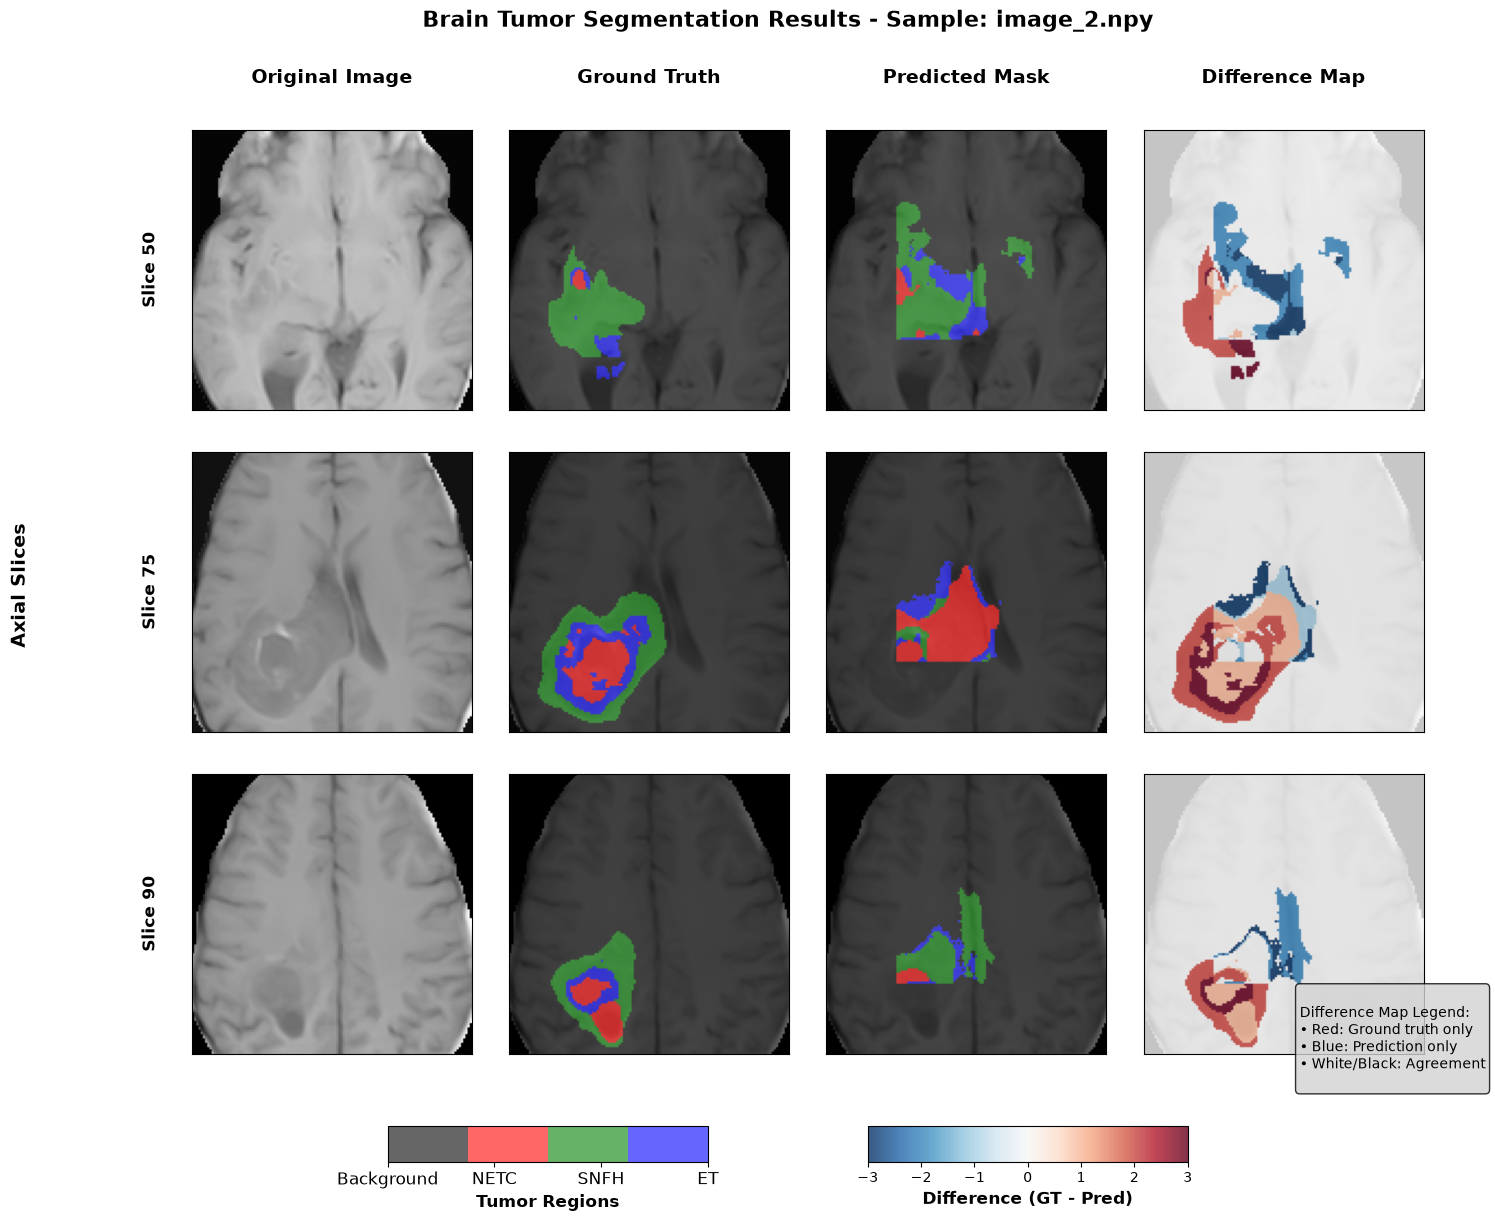


Visualization Statistics:
Original brain shape: (128, 128, 128, 4)
Patch size used for prediction: (64, 64, 64)
Slices displayed: [50, 75, 90]
Ground truth classes present: [0 1 2 3]
Predicted classes present: [0 1 2 3]


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from matplotlib.colors import ListedColormap

# Load the trained model
model = load_model("default_model.keras", compile=False)

# Data paths
DATA_ROOT = "glioma split data"
test_img_dir = os.path.join(DATA_ROOT, "test/images/")
test_mask_dir = os.path.join(DATA_ROOT, "test/masks/")

# Get a test sample
test_img_list = sorted([f for f in os.listdir(test_img_dir) if f.endswith('.npy')])
test_mask_list = sorted([f for f in os.listdir(test_mask_dir) if f.endswith('.npy')])

# Load one test sample
sample_idx = 1  # Change this to visualize different samples
test_image = np.load(os.path.join(test_img_dir, test_img_list[sample_idx]))
test_mask = np.load(os.path.join(test_mask_dir, test_mask_list[sample_idx]))

# Define patch size (must match model input size)
patch_size = (64, 64, 64)

# Function to extract center patch
def extract_center_patch(volume, patch_size):
    """Extract center patch from a 3D volume"""
    start_x = (volume.shape[0] - patch_size[0]) // 2
    start_y = (volume.shape[1] - patch_size[1]) // 2
    start_z = (volume.shape[2] - patch_size[2]) // 2
    
    return volume[
        start_x:start_x + patch_size[0],
        start_y:start_y + patch_size[1],
        start_z:start_z + patch_size[2]
    ]

# Extract center patches - use full brain instead of patches for better visualization
# Only use patches for model prediction
image_patch = extract_center_patch(test_image, patch_size)
mask_patch = extract_center_patch(test_mask, patch_size)

# For visualization, use the full brain volumes
viz_image = test_image
viz_mask = test_mask

input_image = np.expand_dims(image_patch, axis=0)
prediction = model.predict(input_image)
predicted_mask = np.argmax(prediction, axis=-1)[0]  

# Convert ground truth to class indices if it's one-hot encoded
if len(mask_patch.shape) == 4:  
    mask_patch = np.argmax(mask_patch, axis=-1)

if len(viz_mask.shape) == 4:
    viz_mask = np.argmax(viz_mask, axis=-1)

# Select specific slices to visualize
slice_numbers = [50, 75, 90]

# Create a colormap for the masks
colors = ['black', 'red', 'green', 'blue']  # 0: background, 1: NETC, 2: SNFH, 3: ET
cmap = ListedColormap(colors)

# Create the figure - adjusted for better text visibility
fig, axes = plt.subplots(3, 4, figsize=(16, 12), 
                        gridspec_kw={'wspace': 0.1, 'hspace': 0.15})
fig.suptitle(f'Brain Tumor Segmentation Results - Sample: {test_img_list[sample_idx]}', 
             fontsize=16, y=0.98, weight='bold')

# Define column titles
column_titles = ['Original Image', 'Ground Truth', 'Predicted Mask', 'Difference Map']

# Add column titles
for j, title in enumerate(column_titles):
    axes[0, j].text(0.5, 1.15, title, transform=axes[0, j].transAxes, 
                   fontsize=14, weight='bold', ha='center', va='bottom')

for i, slice_num in enumerate(slice_numbers):
    # Ensure slice number is within valid range
    if slice_num >= viz_image.shape[2] or slice_num < 0:
        slice_num = max(0, min(slice_num, viz_image.shape[2] - 1))
    
    # Get the slices from full brain
    img_slice = viz_image[:, :, slice_num, 0] if len(viz_image.shape) == 4 else viz_image[:, :, slice_num]
    gt_slice = viz_mask[:, :, slice_num]
    
    # For predicted mask, we need to map patch coordinates to full brain coordinates
    # Create a full-size prediction mask filled with zeros
    full_pred_mask = np.zeros(viz_image.shape[:3])
    
    # Calculate patch position in full brain
    start_x = (viz_image.shape[0] - patch_size[0]) // 2
    start_y = (viz_image.shape[1] - patch_size[1]) // 2
    start_z = (viz_image.shape[2] - patch_size[2]) // 2
    
    # Place the predicted patch in the full brain
    full_pred_mask[
        start_x:start_x + patch_size[0],
        start_y:start_y + patch_size[1],
        start_z:start_z + patch_size[2]
    ] = predicted_mask
    
    pred_slice = full_pred_mask[:, :, slice_num]
    
    # Rotate for proper orientation
    img_slice = np.rot90(img_slice)
    gt_slice = np.rot90(gt_slice)
    pred_slice = np.rot90(pred_slice)
    
    # Normalize image for better contrast
    img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min())
    
    # Apply contrast enhancement
    img_slice = np.power(img_slice, 0.7)  # Gamma correction for better visibility
    
    # Create difference map (ground truth - predicted)
    diff_slice = gt_slice.astype(float) - pred_slice.astype(float)
    
    # Row label
    axes[i, 0].text(-0.15, 0.5, f'Slice {slice_num}', transform=axes[i, 0].transAxes, 
                   fontsize=12, weight='bold', rotation=90, va='center', ha='center')
    
    # Column 1: Original Image with enhanced contrast
    axes[i, 0].imshow(img_slice, cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])
    axes[i, 0].set_aspect('equal')
    
    # Column 2: Ground Truth overlay
    axes[i, 1].imshow(img_slice, cmap='gray', vmin=0, vmax=1)
    gt_display = axes[i, 1].imshow(gt_slice, cmap=cmap, vmin=0, vmax=3, alpha=0.6)
    axes[i, 1].set_xticks([])
    axes[i, 1].set_yticks([])
    axes[i, 1].set_aspect('equal')
    
    # Column 3: Predicted Mask overlay
    axes[i, 2].imshow(img_slice, cmap='gray', vmin=0, vmax=1)
    pred_display = axes[i, 2].imshow(pred_slice, cmap=cmap, vmin=0, vmax=3, alpha=0.6)
    axes[i, 2].set_xticks([])
    axes[i, 2].set_yticks([])
    axes[i, 2].set_aspect('equal')
    
    # Column 4: Difference Map (NEW)
    diff_cmap = ListedColormap(['blue', 'black', 'white', 'red'])  # -3 to +3 range
    axes[i, 3].imshow(img_slice, cmap='gray', vmin=0, vmax=1)
    diff_display = axes[i, 3].imshow(diff_slice, cmap='RdBu_r', vmin=-3, vmax=3, alpha=0.8)
    axes[i, 3].set_xticks([])
    axes[i, 3].set_yticks([])
    axes[i, 3].set_aspect('equal')

# Add colorbars with better positioning and larger text
# Main colorbar for GT and Pred
cbar_ax1 = fig.add_axes([0.25, 0.02, 0.2, 0.03])  # Horizontal colorbar
cbar1 = fig.colorbar(gt_display, cax=cbar_ax1, orientation='horizontal', ticks=[0, 1, 2, 3])
cbar1.ax.set_xticklabels(['Background', 'NETC', 'SNFH', 'ET'], fontsize=12)
cbar1.set_label('Tumor Regions', fontsize=12, weight='bold')

# Difference map colorbar
cbar_ax2 = fig.add_axes([0.55, 0.02, 0.2, 0.03])  # Horizontal colorbar
cbar2 = fig.colorbar(diff_display, cax=cbar_ax2, orientation='horizontal')
cbar2.set_label('Difference (GT - Pred)', fontsize=12, weight='bold')
cbar2.ax.tick_params(labelsize=10)

# Add text annotations for better understanding
fig.text(0.02, 0.5, 'Axial Slices', rotation=90, fontsize=14, weight='bold', 
         va='center', ha='center')

# Add legend for difference map
legend_text = """
Difference Map Legend:
• Red: Ground truth only
• Blue: Prediction only  
• White/Black: Agreement
"""
fig.text(0.82, 0.08, legend_text, fontsize=10, va='bottom', ha='left',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))

plt.tight_layout(rect=[0.05, 0.08, 0.95, 0.95])
plt.show()

# Print some statistics
print(f"\nVisualization Statistics:")
print(f"Original brain shape: {viz_image.shape}")
print(f"Patch size used for prediction: {patch_size}")
print(f"Slices displayed: {slice_numbers}")
print(f"Ground truth classes present: {np.unique(viz_mask)}")
print(f"Predicted classes present: {np.unique(predicted_mask)}")

### Inference Result

The model successfully generated segmentation predictions for the test sample. The original brain volume had a shape of `128 × 128 × 128 × 4`, while a `64 × 64 × 64` patch was extracted for model inference to match the saved model's input requirements.

All four segmentation classes (`0, 1, 2, 3`) were present in both the ground-truth and predicted masks, indicating that the model produced predictions across all defined tumour regions.

### Phase 3 Summary

The pre-trained 3D U-Net was loaded and evaluated without retraining. The model architecture and input dimensions were first verified, revealing that the provided model expects `64 × 64 × 64 × 4` inputs. The evaluation pipeline was therefore adapted from the tutorial's `96 × 96 × 96` patches to `64 × 64 × 64` patches.

The model was then evaluated on the validation and test data using Dice Score, IoU, and HD95, and its predictions were visualized against the ground-truth segmentation masks.